<a href="https://colab.research.google.com/github/TaeHeo-School/qtm151fall2025/blob/main/QTM_151_FINAL_PROJECTVer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="color:lightblue; text-align:center;">Datasci 151 Final Project</h1>

<h3 style="color:lightblue; text-align:center;">Neko, Tae, William</h3>

<h2 style="color:lightblue; text-align:center;">Introduction</h2>

Formula 1 is one of the most popular car-racing competitions, with multiple car manufacturers and top talent teaming up to win the fastest regulated road-course race in the world. Being such a popular racing competition, a key question of viewers, constructors, and talent are the key metrics predicting success. Due to the different interests of viewers, manufacturers, and talent when asking this question (viewers want to generally predict winners, constructors want to pick top talent, and talents want to pick successful teams), we are considering diverse metrics such as average fastest-lap rank, average pit stop time, and constructor nationality to reflect the various levels of consideration. Our analysis confirms driver success has a strong correlation with average fastest-lap rank, a weak correlation for average pit stop time, nearly no correlation with mean race duration, and a continued German and Austrian constructor dominance outside of a general environment where only a few key constructors are vastly more successful than the majority. The following project will be presented as such: data description, cleaning, and merging; selection of success metric, data analysis, and confirmation through multivariate models, and conclusion.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

<h2 style="color:lightblue; text-align:center;">Preliminary Data Description</h2>

First, given that the project required data cleaning, numerical calculation, and plotting, we imported three libraries - pandas, numpy, and matplotlib.pyplot.

We used four data throughout the analysis - results.csv, constructors.csv, drivers.csv, and pit_stops.csv.

results.csv: The data has 25660 rows, where each observational unit is a specific driver's performance in a specific race. The variables we are interested in are points, millisecond, and rank. Points here means the numerical points awarded to the driver based on their finishing position. We would use this as our response variable in some analysis. Millisecond in this dataset means the race duration a driver takes. The units was changed to minutes in subsequent data analysis. This is another measure for the drivers' performance. Points demonstrates a driver's comparative performance, while the race duration shows a driver's absolute performance. We provide both for subsequent data analysis. Rank means the order of the driver's fastest lap compared to other drivers in the same race. Given the bonus point system in F1, we want to see if rank have any effect on points.

constructors.csv: The data has 211 rows, where each observational unit is a specific constructor. The variable we are interested in is the constructor's nationality. There's always debate on which country produces the best cars. Thus, we want to see if constructor's nationality have any effect on points.

drivers.csv: The data has 854 rows, where each observational unit is a specific driver/racer. The variable we are interested in are the driver's nationality and date of birth. We want to see which countries have the most drivers or better driver performance. The date of birth could be a variable or controlled factor. It might be the case that older drivers were more experienced. However young drivers may have more enhanced race cars and better equipments.

pit_stops.csv: The data has 9299 rows, where each observational unit is a specific driver in a specific races' specific stop. The variable we are interested in is duration, which is the pit stop time. Note some calculated the pit stop time to be only the time for changing tire, which should be about 2 to 3 seconds on average. This dataset used another definition of pit stop time that also included pit stop duration and pit lane entry/exit time. We want to see if pit stop time have any effect on drivers' points.

races.csv: The data has 1079 rows, where each observational unit is a specific race. The variable we are interested in is year, the time the race took place in. Again, this variable is needed for controlling any biases given that drivers' performances  in different year segments weren't apple to apple comparisons. It should be strongly related with the race duration given technological improvements.



In [ ]:
import os

# Check if the folder exists, otherwise look in current directory
data_dir = "1-Formula_One/"
if not os.path.exists(data_dir):
    data_dir = ""

df_results = pd.read_csv(os.path.join(data_dir, "results.csv"))
df_constructors = pd.read_csv(os.path.join(data_dir, "constructors.csv"))
df_drivers = pd.read_csv(os.path.join(data_dir, "drivers.csv"))
df_pitstops = pd.read_csv(os.path.join(data_dir, "pit_stops.csv"))
df_races = pd.read_csv(os.path.join(data_dir, "races.csv"))

display(len(df_results))
display(len(df_constructors))
display(len(df_drivers))
display(len(df_pitstops))
display(len(df_races))
#mean_pit_stop_time=(df_pitstops_exclude_outlier["milliseconds"].mean())/1000

25660

211

854

9299

1079

<h2 style="color:lightblue; text-align:center;">Data Cleaning</h2>

We first converted several quantitative variables to numeric format by replacing all non-numeric values with np.nan. Then, we renamed some variables to avoid confusion; for example, we clarified the difference between "constructor_nationality" and "driver_nationality" due to both initially being labelled as "nationality" in their original documents.

Major adjustments were made to the pitstops.csv dataset. We noticed that several pit stop times were extremely large, which skewed the average value significantly. These instances likely represent rare situations where the racing car was severely damaged and did not finish the race. Since these are exceptional cases, we decided to remove them so that they would not disproportionately affect the mean values.

We also refined the time variables. For time-related fields, we converted them to datetime format to enable correct plotting of graphs and further time-series analysis. For the year variable in race.csv, we recoded it into categorical variables to better suit our data analysis objectives.

In [ ]:

df_results = df_results[["resultId","raceId","driverId","constructorId","points","rank","milliseconds"]]
df_results["race_time_ms"] = pd.to_numeric(df_results["milliseconds"], errors = "coerce")
df_results['race_duration_minutes'] = df_results['race_time_ms'] / (1000*60)
df_results["rank"] = pd.to_numeric(df_results["rank"], errors='coerce')
df_results["points"] = pd.to_numeric(df_results["points"], errors='coerce')
df_constructors.rename(columns={'nationality':'constructor_nationality'}, inplace=True)
df_drivers.rename(columns={'nationality':'driver_nationality'}, inplace=True)
df_drivers['date_of_birth'] = pd.to_datetime(df_drivers['dob'], format='%Y-%m-%d')
df_pitstops_exclude_outlier=df_pitstops.query("milliseconds<50000")
df_pitstops_groupby = (df_pitstops_exclude_outlier.groupby(["driverId"])
                        .agg(mean_pit_stop_time = ('milliseconds','mean')).reset_index())

# Corrected: Divide by 1000 to convert milliseconds to seconds
df_pitstops_groupby["mean_pit_stop_time"] = np.round(df_pitstops_groupby["mean_pit_stop_time"]/1000,2)

lat_bins = [1950, 1960, 1970,1980,1990,2000,2010,2023]
lat_labels = ["1950-1960", "1960-1970","1970-1980","1980-1990","1990-2000","2000-2010","2010-2022"]
df_races["year_segment"] = pd.cut(df_races["year"],
                                bins = lat_bins,
                              right = False,
                               labels = lat_labels)

<h2 style="color:lightblue; text-align:center;">Data Merging</h2>

Lastly, we merged all five datasets based on the ID numbers shared by both datasets through each round of merging.

Result.csv is our main dataset. We appended constructors.csv, drivers.csv, race.csv, and pitstops.csv in order.

In [ ]:
merge_1 = pd.merge(left = df_results,
                       right = df_constructors[["constructorId", "constructor_nationality"]],
                       on = "constructorId",
                       how = "left")
merge_2 = pd.merge(left = merge_1,
                       right = df_drivers[["driverId", "driver_nationality","date_of_birth"]],
                       on = "driverId",
                       how = "left")

merge_3 = pd.merge(left = merge_2,
                   right = df_races[["raceId","year_segment"]],
                   on = "raceId",
                   how = "left")
final_merge = pd.merge(left = merge_3,
                       right = df_pitstops_groupby[["driverId", "mean_pit_stop_time"]],
                       on = "driverId",
                       how = "left")


<h2 style="color:lightblue; text-align:center;"> Main Dataset After Cleaning</h2>

Lastly, we grouped the data by driver and constructor, and calculated relevant statistics for each combination. We removed any rows where the standard deviation of race duration was zero (indicating only one observational unit) or where there were missing values, in order to avoid bias in our results.

In addition to using the categorical variables described in the data documentation, we created several descriptive quantitative variables: the mean and standard deviation for points, the mean and standard deviation for race duration (in minutes), and the mean pit stop time (in seconds). These variables serve as references and will be utilized in further stages of our data analysis.

In [ ]:
result_groupby = (final_merge.groupby(["driverId","constructorId"])
                        .agg(mean_rank = ('rank','mean'),
                             sd_rank = ('rank','std'),
                             mean_race_duration_minutes = ('race_duration_minutes','mean'),
                             sd_race_duration_minutes = ('race_duration_minutes','std'),
                             mean_points = ('points','mean'),
                             sd_points = ('points','std'),
                             driver_nationality = ('driver_nationality', 'first'),
                      constructor_nationality = ('constructor_nationality', 'first'),
                      mean_pit_stop_time_second= ('mean_pit_stop_time','first'),
                      year_segment = ('year_segment','first'),
                      date_of_birth = ('date_of_birth', 'first'),).reset_index())

result_groupby["specific_driver_constructor"] = (
    result_groupby["driverId"].astype(str) + " & " +
    result_groupby["constructorId"].astype(str)
)
final_result = result_groupby.query('sd_race_duration_minutes!=0 & sd_race_duration_minutes.notna()')
display(final_result)


,driverId,constructorId,mean_rank,sd_rank,mean_race_duration_minutes,sd_race_duration_minutes,mean_points,sd_points,driver_nationality,constructor_nationality,mean_pit_stop_time_second,year_segment,date_of_birth,specific_driver_constructor
0,1,1,6.046296,5.226432,97.280427,14.860624,8.300000,7.566888,British,British,23.48,2000-2010,1985-01-07,1 & 1
1,1,131,3.759162,3.380222,97.021280,16.764644,17.777487,8.316374,British,German,23.48,2010-2022,1985-01-07,1 & 131
2,2,2,8.318841,4.258185,93.419844,10.735130,2.328571,2.512124,German,German,22.93,2000-2010,1977-05-10,2 & 2
3,2,3,9.615385,4.292211,95.419007,6.639977,2.000000,3.113247,German,British,22.93,2000-2010,1977-05-10,2 & 3
4,2,4,12.818182,6.615409,94.379271,4.369270,3.090909,4.526689,German,French,22.93,2010-2022,1977-05-10,2 & 4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2125,849,3,15.057692,4.569350,97.518248,31.864266,0.134615,0.840841,Canadian,British,25.36,2010-2022,1995-06-29,849 & 3
2128,852,213,9.885714,6.023344,101.427097,36.974422,1.228571,2.734160,Japanese,Italian,25.15,2010-2022,2000-05-11,852 & 213
2129,853,210,15.318182,7.504832,68.914908,91.825605,0.000000,0.000000,Russian,American,25.52,2010-2022,1999-03-02,853 & 210
2130,854,210,13.485714,5.710524,91.971940,44.293469,0.342857,1.493965,German,American,25.99,2010-2022,1999-03-22,854 & 210



<h2 style="color:lightblue; text-align:center;">Research Question and Success Metric</h2>

Our driver success metric is the average race points scored per driver-constructor pairing. This was chosen as opposed to other metrics (i.e. frequency of being in top 3, fastest lap time) due to better capturing mid-tier driver success while judging performace within context. We consider three characteristics as potential predictors of success: (1) average fastest-lap rank (lower is better), (2) average pit stop time per driver, and (3) average race duration. We also keep constructor nationality to see whether team context shifts performance. Below we quantify relationships with plots/correlations and then try simple models (linear regression, decision tree, and a KNN classifier for "top-quartile" success)**.

**ML methods is not covered by DSCI 151. But as group member have taken CS334-Machine Learning already, data will be remaining used for cross validation


Average points per driver-constructor:


,count,mean,std,min,25%,50%,75%,max
mean_points,476.0,2.001164,2.267603,0.0,0.542424,1.413043,2.561404,17.777487


Correlation with mean_points (success):


,mean_points
mean_points,1.000000
mean_race_duration_minutes,-0.157333
mean_pit_stop_time_second,-0.241282
mean_rank,-0.775504


Fastest-lap rank R^2: 0.565 (n=156)


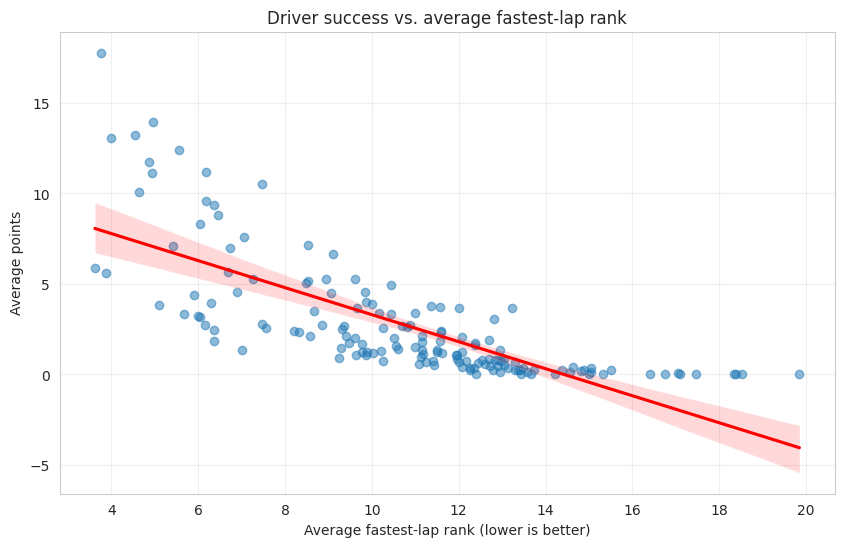

Pit stop R^2: 0.052 (n=143)


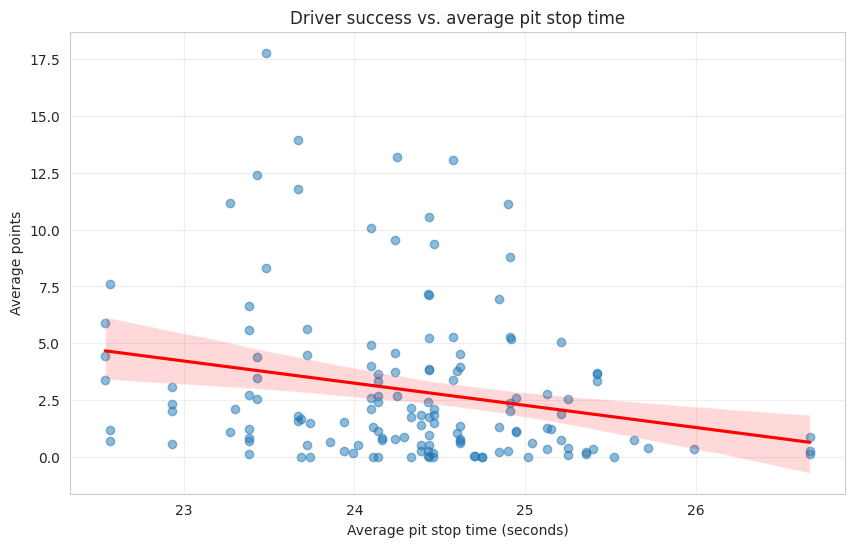

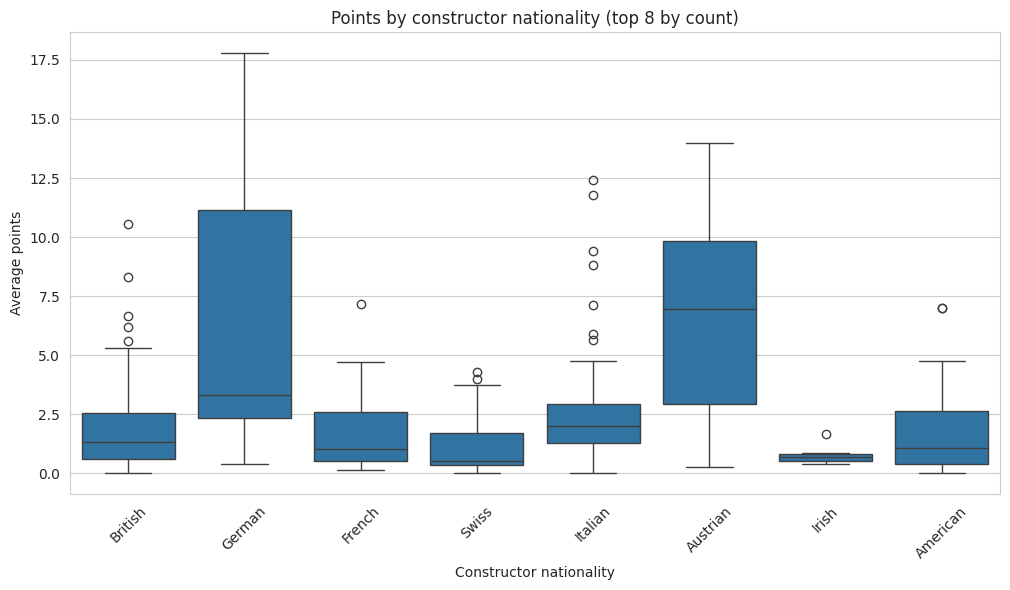

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

analysis_df = final_result[
    [
        "specific_driver_constructor",
        "mean_points",
        "mean_rank",
        "mean_pit_stop_time_second",
        "mean_race_duration_minutes",
        "constructor_nationality",
    ]
].dropna(subset=["mean_points"])

# Summary of the success metric and quick correlations
print("Average points per driver-constructor:")
display(analysis_df[["mean_points"]].describe().T)

corr_cols = [
    "mean_points",
    "mean_rank",
    "mean_pit_stop_time_second",
    "mean_race_duration_minutes",
]
corr_to_success = analysis_df[corr_cols].dropna().corr()["mean_points"].sort_values(ascending=False)
print("Correlation with mean_points (success):")
display(corr_to_success)

# 1) Fastest-lap rank vs. success
rank_df = analysis_df.dropna(subset=["mean_rank"])
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mean_rank",
    y="mean_points",
    data=rank_df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
plt.title("Driver Success vs. Average Fastest-Lap Rank")
plt.xlabel("Average Fastest-Lap Rank (lower is better)")
plt.ylabel("Average Points")
plt.grid(True, alpha=0.3)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    rank_df["mean_rank"], rank_df["mean_points"]
)
print(f"Fastest-lap rank R^2: {r_value**2:.3f} (n={len(rank_df)})")
plt.show()

# 2) Pit stop speed vs. success
pit_df = analysis_df.dropna(subset=["mean_pit_stop_time_second"])
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mean_pit_stop_time_second",
    y="mean_points",
    data=pit_df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
plt.title("Driver Success vs. Average Pit Stop Time")
# Corrected label to Seconds
plt.xlabel("Average Pit Stop Time (s)")
plt.ylabel("Average Points")
plt.grid(True, alpha=0.3)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    pit_df["mean_pit_stop_time_second"], pit_df["mean_points"]
)
print(f"Pit stop R^2: {r_value**2:.3f} (n={len(pit_df)})")
plt.show()

# 3) Average Race Duration vs. Success
pit_df = analysis_df.dropna(subset=["mean_race_duration_minutes"])
plt.figure(figsize=(10, 6))
sns.regplot(
    x="mean_race_duration_minutes",
    y="mean_points",
    data=pit_df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"},
)
plt.title("Driver Success vs. Mean Race Duration (min)")
# Corrected label to Seconds
plt.xlabel("Mean Race Duration (min)")
plt.ylabel("Average Points")
plt.grid(True, alpha=0.3)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    pit_df["mean_pit_stop_time_second"], pit_df["mean_points"]
)
print(f"Mean Race Duration R^2: {r_value**2:.3f} (n={len(pit_df)})")
plt.show()

# 4) Constructor context: restrict to top constructors by sample size for a readable plot
top_cons = analysis_df["constructor_nationality"].value_counts().nlargest(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="constructor_nationality",
    y="mean_points",
    data=analysis_df[analysis_df["constructor_nationality"].isin(top_cons)],
)
plt.title("Points by Constructor Nationality (top 8 by count)")
plt.xlabel("Constructor Nationality")
plt.ylabel("Average Points")
plt.xticks(rotation=45)
plt.show()

Driver Success vs Average Fastest-Lap Rank has a strong correlation with an R^2 value of 0.565. Average Fastest-Lap Rank is understood to be the average rank a driver was on their fastest lap of any given race. In a sense, it can be understood as the average of any particular driver's best performances. Given that driver success is defined by average points scored, and points are given based off the final ranking of each driver in a race, it is expected that driver success and average fastest-lap rank should be strongly correlated, and this is supported by our findings. There is some skewing past around 14th place on average fastest-lap rank due to the Formula 1 point scoring system rewarding 0 points past 10th place, leading to a flat zone. The low density of datapoints past averaging 5th place for fastest-lap rank also emphasizes the limit of the correlation between average fastest-lap rank and average points scored, as certain drivers may have early leads, leading to low average fastest-lap rank, but fail to maintain this lead, leading to low average points scored.

Driver Success vs Average Pit Stop Time has a weak correlation with an R^2 value of 0.052. While relatively high average pit stop times values coincided with low average points, overall average pit stop times were centered around 24 and 25 seconds regardless of performance. While the 2 most successful drivers had pitstop times between 23 and 24 seconds, the much greater number of drivers with times between 24 and 25 seconds keeps average pit stop times a weak predictor of driver success.

Driver Success vs Average Race Duration has almost no correlation, with a near-zero R^2 value. While it is expected that a lower average race duration would lead to finishing higher in races, leading to greater driver success, our finding suggests almost no correlation between the two variables. This can be intuited by units: while performance gaps are often measured in seconds, the range for mean race duration stretches past 2 hours. More precisely, because driver success does not consider factors such as race-by-race performance, the year a race took place, or if drivers even drove against each other, random factors such as a driver's particular luck with weather, the technology they had access to, and the rules of Formula 1 at the time, this direct comparison does not work, and our lack of correlation makes sense. Comparison would likely require some standardization, such as utilizing the difference in finishing time between first place and the driver in question, and finding the average of the compared values. Even still, our comparison could be limited due to growing competitiveness in Formula 1 narrowing the gap.

Constructor nationality highlights two observations: German-Austrian constructor dominance and the prevalence of outliers for other countries. German and Austrian constructors at the top quartile vastly outperform every other country's constructors in terms of average points scored. This matches common wisdom: constructors such as Red Bull (Austria) and Mercedes (Germany) are well known for their consistent high performance. However, this data also shows the prevalence of outliers, seen by the dots above the box plots on the graph. Constructors such as McLaren (United Kingdom) and Ferrari (Italy) are also consistent high performers, but they are outliers within their country. Due to the high performance of outliers, the actual dominance of German and Austrian constructors can look much less overwhelming.

1.Advanced Analysis: Modeling Driver Success

To further validate our findings, we moved beyond simple correlations to multivariate machine learning models. We used Linear Regression to quantify the impact of each variable while holding others constant, and a KNN Classifier to see if we could predict whether a driver belongs to the top 25% performers based solely on their race statistics.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

feature_cols = ["mean_rank", "mean_pit_stop_time_second", "mean_race_duration_minutes"]
model_df = final_result.dropna(subset=feature_cols + ["mean_points"]).copy()

X = model_df[feature_cols]
y = model_df["mean_points"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression baseline
lin_reg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_test)
print(f"Linear regression R^2: {r2_score(y_test, lin_preds):.3f}")
coeffs = pd.Series(lin_reg.named_steps["model"].coef_, index=feature_cols)
print("Linear regression coefficients (scaled features):")
display(coeffs.sort_values())

# Decision tree to allow non-linear splits
tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)
print(f"Decision tree R^2: {r2_score(y_test, tree_preds):.3f}")

# KNN classifier: label top-quartile performers as 1, others 0
classification_df = model_df.copy()
threshold = classification_df["mean_points"].quantile(0.75)
classification_df["success_flag"] = (classification_df["mean_points"] >= threshold).astype(int)
Xc = classification_df[feature_cols]
yc = classification_df["success_flag"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc,
    yc,
    test_size=0.2,
    random_state=42,
    stratify=yc,
)
knn = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7)),
    ]
)
knn.fit(Xc_train, yc_train)
yc_pred = knn.predict(Xc_test)
print(f"KNN accuracy (top quartile vs. rest): {accuracy_score(yc_test, yc_pred):.3f}")
print(
    classification_report(
        yc_test, yc_pred, target_names=["not top quartile", "top quartile"]
    )
)

Linear regression R^2: 0.523
Linear regression coefficients (scaled features):


,0
mean_rank,-2.872516
mean_pit_stop_time_second,0.042479
mean_race_duration_minutes,0.527120


Decision tree R^2: 0.712
KNN accuracy (top quartile vs. rest): 0.963
                  precision    recall  f1-score   support

not top quartile       0.95      1.00      0.98        20
    top quartile       1.00      0.86      0.92         7

        accuracy                           0.96        27
       macro avg       0.98      0.93      0.95        27
    weighted avg       0.96      0.96      0.96        27



2. Model Optimization (Cross-Validation & Grid Search)

 To ensure our results are robust and not just due to a lucky data split, we implemented 5-fold Cross-Validation. We also performed Grid Search to find the optimal hyperparameters for our non-linear models.

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

feature_cols = ["mean_rank", "mean_pit_stop_time_second", "mean_race_duration_minutes"]
model_df = final_result.dropna(subset=feature_cols + ["mean_points"]).copy()

X = model_df[feature_cols]
y = model_df["mean_points"]

# 5-fold CV for linear regression (baseline)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
lin_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_cv_scores = cross_val_score(lin_cv_model, X, y, cv=kfold, scoring="r2")
print(f"Linear regression 5-fold R^2: {lin_cv_scores.mean():.3f} +/- {lin_cv_scores.std():.3f}")

# Grid search for decision tree depth/leaf size with 5-fold CV
tree_params = {
    "max_depth": [3, 4, 5, 6, None],
    "min_samples_leaf": [1, 2, 5, 10],
}
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=kfold,
    scoring="r2",
)
tree_search.fit(X, y)
print(f"Decision tree best 5-fold R^2: {tree_search.best_score_:.3f}")
print("Best params:", tree_search.best_params_)

# KNN classifier tuned via 5-fold CV (top-quartile vs. rest)
classification_df = model_df.copy()
threshold = classification_df["mean_points"].quantile(0.75)
classification_df["success_flag"] = (classification_df["mean_points"] >= threshold).astype(int)
Xc = classification_df[feature_cols]
yc = classification_df["success_flag"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),
])
knn_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
}
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=skf, scoring="accuracy")
knn_search.fit(Xc, yc)
print(f"KNN best 5-fold accuracy: {knn_search.best_score_:.3f}")
print("Best params:", knn_search.best_params_)


Linear regression 5-fold R^2: 0.601 +/- 0.054
Decision tree best 5-fold R^2: 0.738
Best params: {'max_depth': 5, 'min_samples_leaf': 1}
KNN best 5-fold accuracy: 0.887
Best params: {'model__n_neighbors': 9, 'model__weights': 'uniform'}


<h2 style="color:lightblue; text-align:center;">Discussion</h2>

Our analysis shows a strong correlation for the average fastest-lap rank, weak correlation for the average pit stop time, and nearly no correlation for average race duration to the average points a driver scored, our metric for driver success. A closer look at the graphs show that average fastest-lap rank was strongly correlated, driver success was weakly correlated with average pit stop times outside of the most extreme cases due to how heavily centralized average pit stop times are around 240-246 regardless of driver performance, and that average race duration was essentially not correlated to the average points scored due to race duration range being far larger than the actual margins at which races are won by, implying a more robust comparison would have to differentiate between races. Constructor nationality both shows a dominance by the German and Austrian constructors, but also a large gap between top and average constructors regardless of nationality, emphasizing how Formula One continues to be dominated by a select few constructors who can make it into the top 10 of any particular race out of the 211 unique constructors who participate.
